# Inference & Visualization

This notebook demonstrates how to:
1. Load a trained model checkpoint
2. Run inference on sample data
3. Visualize channel estimation results

**Prerequisites:** 
- Run `01_data_setup.ipynb` to prepare data
- Run `02_training.ipynb` to train at least one model

In [2]:
import sys
from pathlib import Path

# Add project root to path for imports
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.4.1+cu121
CUDA available: True


## 1. Find Available Checkpoints

In [3]:
# Find all available checkpoints
runs_dir = PROJECT_ROOT / "runs"
checkpoints = []

if runs_dir.exists():
    for ckpt in runs_dir.rglob("*.pt"):
        checkpoints.append(ckpt)
    
    if checkpoints:
        print("Available checkpoints:")
        print("="*60)
        for i, ckpt in enumerate(checkpoints):
            rel_path = ckpt.relative_to(PROJECT_ROOT)
            print(f"[{i}] {rel_path}")
    else:
        print("No checkpoints found. Please train a model first using 02_training.ipynb")
else:
    print("No runs directory found. Please train a model first using 02_training.ipynb")

Available checkpoints:
[0] runs/fortitran_fortitran_demo/periodic/checkpoint_epoch_9.pt
[1] runs/linear_linear_demo/periodic/checkpoint_epoch_9.pt
[2] runs/adafortitran_adafortitran_demo/periodic/checkpoint_epoch_9.pt


## 2. Load Model Checkpoint

Select a checkpoint index from the list above.

In [4]:
# Select checkpoint (change this index to use a different checkpoint)
CHECKPOINT_INDEX = 0  # Change this to select a different checkpoint

if checkpoints:
    checkpoint_path = checkpoints[CHECKPOINT_INDEX]
    print(f"Selected checkpoint: {checkpoint_path.relative_to(PROJECT_ROOT)}")
else:
    checkpoint_path = None
    print("No checkpoint available!")

Selected checkpoint: runs/fortitran_fortitran_demo/periodic/checkpoint_epoch_9.pt


In [5]:
from src.models import LinearEstimator, FortiTranEstimator, AdaFortiTranEstimator

# Model registry
MODEL_REGISTRY = {
    "linear": LinearEstimator,
    "fortitran": FortiTranEstimator,
    "adafortitran": AdaFortiTranEstimator,
}

def load_model(checkpoint_path, device="cpu"):
    """Load model from checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    system_config = checkpoint['system_config']
    model_config = checkpoint['model_config']
    
    # Get model name
    if 'args' in checkpoint and hasattr(checkpoint['args'], 'model_name'):
        model_name = checkpoint['args'].model_name
    else:
        model_name = model_config.model_type
    
    # Initialize model
    model_class = MODEL_REGISTRY[model_name]
    model = model_class(system_config, model_config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model, system_config, model_config, model_name, checkpoint

In [7]:
# Load the model
if checkpoint_path:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, system_config, model_config, model_name, checkpoint = load_model(checkpoint_path, device)
    
    print(f"   Model loaded successfully!")
    print(f"   Model type: {model_name}")
    print(f"   Training epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"   Validation loss: {checkpoint.get('val_loss', 'N/A'):.6f}" if checkpoint.get('val_loss') else "   Validation loss: N/A")
    print(f"   Device: {device}")
else:
    print("Cannot load model - no checkpoint available")

   Model loaded successfully!
   Model type: fortitran
   Training epoch: 9
   Validation loss: 0.122000
   Device: cuda


/tmp/ipykernel_3300537/1606491420.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


## 3. Load Sample Data

In [8]:
from src.data import MatDataset
from torch.utils.data import DataLoader

# Load validation data for inference demo
VAL_DIR = PROJECT_ROOT / "data" / "val"

if VAL_DIR.exists() and list(VAL_DIR.glob("*.mat")):
    dataset = MatDataset(VAL_DIR, system_config.pilot)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
    
    print(f"Loaded {len(dataset)} samples from validation set")
else:
    print("No validation data found. Run 01_data_setup.ipynb first!")

Loaded 200 samples from validation set


## 4. Run Inference

In [9]:
# Get a batch of data
batch = next(iter(dataloader))
ls_estimate, ideal_channel, meta_data = batch

print(f"Input shape (LS estimate at pilots): {ls_estimate.shape}")
print(f"Target shape (ideal channel): {ideal_channel.shape}")
print(f"Metadata: SNR={meta_data[1][0].item()}, DS={meta_data[2][0].item()}, DOP={meta_data[3][0].item()}")

Input shape (LS estimate at pilots): torch.Size([8, 40, 2])
Target shape (ideal channel): torch.Size([8, 120, 14])
Metadata: SNR=10.0, DS=75.0, DOP=750.0


In [10]:
# Run inference
model.eval()
with torch.no_grad():
    if model_name == "adafortitran":
        # AdaFortiTran needs metadata for channel adaptation
        predicted_channel = model(ls_estimate, meta_data)
    else:
        # Linear and FortiTran don't use metadata
        predicted_channel = model(ls_estimate)

print(f"Predicted channel shape: {predicted_channel.shape}")

Predicted channel shape: torch.Size([8, 120, 14])


## 5. Visualize Results

Compare the predicted channel with the ground truth.

In [11]:
def plot_channel_comparison(ideal, predicted, sample_idx=0):
    """Plot ideal vs predicted channel comparison."""
    # Get single sample
    h_ideal = ideal[sample_idx].numpy()
    h_pred = predicted[sample_idx].numpy()
    
    # Compute magnitude (absolute value of complex channel)
    h_ideal_mag = np.abs(h_ideal)
    h_pred_mag = np.abs(h_pred)
    h_error = np.abs(h_ideal - h_pred)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Ground truth
    im0 = axes[0].imshow(h_ideal_mag, aspect='auto', cmap='viridis')
    axes[0].set_title('Ground Truth Channel')
    axes[0].set_xlabel('OFDM Symbol')
    axes[0].set_ylabel('Subcarrier')
    plt.colorbar(im0, ax=axes[0], label='Magnitude')
    
    # Predicted
    im1 = axes[1].imshow(h_pred_mag, aspect='auto', cmap='viridis')
    axes[1].set_title('Predicted Channel')
    axes[1].set_xlabel('OFDM Symbol')
    axes[1].set_ylabel('Subcarrier')
    plt.colorbar(im1, ax=axes[1], label='Magnitude')
    
    # Error
    im2 = axes[2].imshow(h_error, aspect='auto', cmap='hot')
    axes[2].set_title('Absolute Error')
    axes[2].set_xlabel('OFDM Symbol')
    axes[2].set_ylabel('Subcarrier')
    plt.colorbar(im2, ax=axes[2], label='|Error|')
    
    plt.tight_layout()
    return fig

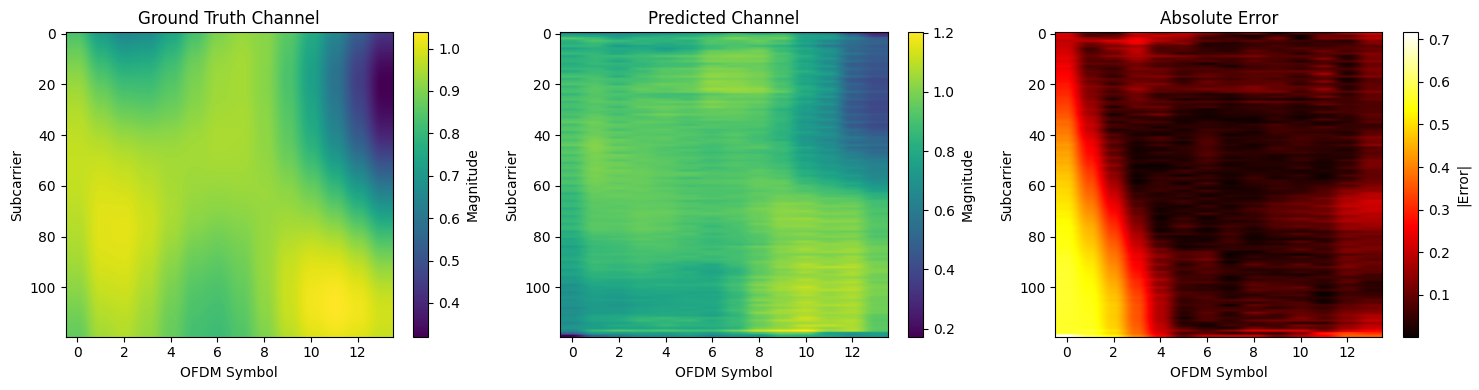

In [12]:
# Plot comparison for first sample
fig = plot_channel_comparison(ideal_channel, predicted_channel, sample_idx=0)
plt.show()

## 6. Compute Error Metrics

In [13]:
from src.utils import concat_complex_channel, to_db

def compute_nmse(predicted, ideal):
    """Compute Normalized MSE between predicted and ideal channels."""
    # Convert complex to real (concat real and imag parts)
    pred_real = concat_complex_channel(predicted)
    ideal_real = concat_complex_channel(ideal)
    
    # NMSE = ||predicted - ideal||^2 / ||ideal||^2
    mse = torch.sum((pred_real - ideal_real) ** 2).item()
    power = torch.sum(ideal_real ** 2).item()
    nmse = mse / power
    return nmse

# Compute NMSE for the batch
nmse = compute_nmse(predicted_channel, ideal_channel)
nmse_db = to_db(nmse)

print(f"Batch NMSE: {nmse:.6f}")
print(f"Batch NMSE (dB): {nmse_db:.2f} dB")

Batch NMSE: 0.161802
Batch NMSE (dB): -7.91 dB


## 7. Batch Inference Example

Run inference on multiple batches and aggregate results.

In [14]:
# Evaluate on entire validation set
total_mse = 0.0
total_power = 0.0
num_samples = 0

model.eval()
with torch.no_grad():
    for batch in dataloader:
        ls_est, ideal, meta = batch
        
        if model_name == "adafortitran":
            pred = model(ls_est, meta)
        else:
            pred = model(ls_est)
        
        # Accumulate MSE and power for NMSE
        pred_real = concat_complex_channel(pred)
        ideal_real = concat_complex_channel(ideal)
        total_mse += torch.sum((pred_real - ideal_real) ** 2).item()
        total_power += torch.sum(ideal_real ** 2).item()
        
        num_samples += ls_est.size(0)

# Compute NMSE
avg_nmse = total_mse / total_power
avg_nmse_db = to_db(avg_nmse)

print(f"="*50)
print(f"Validation Set Results ({num_samples} samples)")
print(f"="*50)
print(f"Average NMSE: {avg_nmse:.6f}")
print(f"Average NMSE (dB): {avg_nmse_db:.2f} dB")

Validation Set Results (200 samples)
Average NMSE: 0.159763
Average NMSE (dB): -7.97 dB


---

## Summary

This notebook demonstrated:
- Loading a trained model checkpoint
- Running inference on sample data
- Visualizing channel estimation results
- Computing error metrics

For comprehensive test set evaluation across different channel conditions (SNR, Delay Spread, Doppler), use the evaluation script:

```bash
python src/evaluate.py \
    --checkpoint_path <your_checkpoint.pt> \
    --test_set data/test \
    --output_dir results/
```